In [1]:
import pandas as pd
import numpy as np 

# Importations pour la construction du modèle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Lambda

# Importation pour la transformation sur les images
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation

# Importation pour utiliser un modèle pre entrainé
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from keras.optimizers import Adam

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation pour les visualisations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from metrics import MacroMetricsCallback

from sklearn.utils.class_weight import compute_class_weight

#from models.gradcam import GradCAM
#from models.gradcam import show_gradcam

#import random

print("Opération terminée")

Opération terminée


1. Chargement des images

In [2]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_split"

train_ds = image_dataset_from_directory(
    directory=chemin+"/train_augmented/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='rgb' 
)

test_ds = image_dataset_from_directory(
    directory=chemin+"/test/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
   color_mode='rgb'
    
)

val_ds = image_dataset_from_directory(
    directory=chemin+"/validation/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
    
)


Found 33336 files belonging to 4 classes.


2026-07-21 16:20:29.199826: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-07-21 16:20:29.199896: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-21 16:20:29.199900: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1784643629.200003  871821 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784643629.200152  871821 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 2084 files belonging to 4 classes.
Found 2083 files belonging to 4 classes.


In [3]:
#Calcul des poids de chaque classe dans le jeu de données d'origine

train_ds_not_augmented = image_dataset_from_directory(
    directory=chemin+"/train/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='rgb' 
)


y_train_not_augmented = np.concatenate([labels for images, labels in train_ds_not_augmented], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_not_augmented), y=y_train_not_augmented)
class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

Found 16668 files belonging to 4 classes.
{0: np.float64(1.544477390659748), 1: np.float64(0.8697557921102066), 2: np.float64(0.5138734739178691), 3: np.float64(3.894392523364486)}


2026-07-21 16:20:36.566053: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
print(train_ds.class_names)
print(val_ds.class_names)
print(test_ds.class_names)

for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Images : (32, 224, 224, 3)
Labels : (32,)


2026-07-21 16:20:42.507258: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
#Prétraitement des images pour la compatibilité avec le modèle EfficienNet
train_ds=train_ds.map(lambda x,y: (preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y: (preprocess_input(x),y))
tes_ds=test_ds.map(lambda x,y: (preprocess_input(x),y))

In [6]:
for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

Images : (32, 224, 224, 3)
Labels : (32,)


2. Visualisation du jeu de données

2026-07-21 16:20:50.501964: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


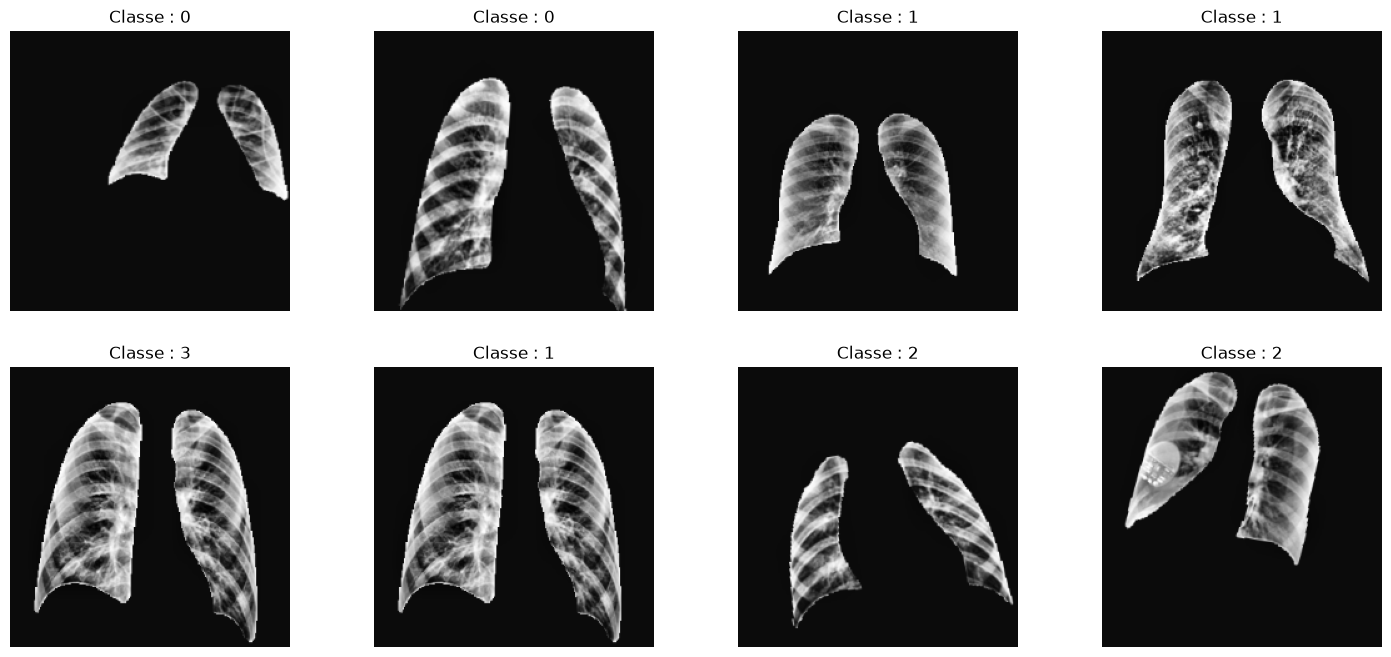

In [7]:
number_of_image=8

fig=plt.figure (figsize=(18,8))

for images, label in train_ds.take(1):
    for i in range(number_of_image):
        plt.subplot(2,4,i+1)
        indice=np.random.randint(len(label))
        plt.imshow(images[indice].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(f"Classe : {label[i].numpy()}")


plt.show()

3. Chargement du modèle

In [8]:
#Choix du device
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
base_model=EfficientNetB0(weights="imagenet", include_top=False)

#Gel des couches

base_model.trainable = False

base_model

<Functional name=efficientnetb0, built=True>

In [10]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
inputs=Input(shape=(224, 224, 3), name="Input")

x=base_model(inputs)

x=GlobalAveragePooling2D()(x)
x=Dropout(0.3)(x)
x=Dense(units=128, activation="relu")(x)
x=Dropout(0.3)(x)
outputs=Dense(units=4, activation="softmax", name="output_layer")(x)

model=Model(inputs=inputs, outputs=outputs)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

4. Création de callbacks et d'un early stopping

In [13]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=5,
                             min_delta=0.01,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [14]:
#Création d'une fonction pour suivre le f1-score à chaque epoch
from metrics import MacroMetricsCallback

macro_metrics = MacroMetricsCallback(train_ds, val_ds)
    

5. Compilation et entraînement du modèle

In [15]:
optimizer=Adam(1e-4)

In [16]:
#Compilation du modèle

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [17]:
#Entraînement du modèle

model_history=model.fit(train_ds, validation_data=val_ds,
                        epochs=40,
                        class_weight=class_weight_dict,
                        callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

Epoch 1/40


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-21 16:23:13.526270: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6252 - loss: 0.8111
Train F1 : 0.7043 | Val F1 : 0.6951
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 612s 579ms/step - accuracy: 0.6252 - loss: 0.8111 - val_accuracy: 0.7211 - val_loss: 0.6750 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7043 - val_f1_macro: 0.6951
Epoch 2/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.6939 - loss: 0.6656
Train F1 : 0.7180 | Val F1 : 0.7079
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 589s 566ms/step - accuracy: 0.6939 - loss: 0.6656 - val_accuracy: 0.7283 - val_loss: 0.6519 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7180 - val_f1_macro: 0.7079
Epoch 3/40


2026-07-21 16:43:13.602313: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7124 - loss: 0.6252
Train F1 : 0.7447 | Val F1 : 0.7306
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 581s 558ms/step - accuracy: 0.7124 - loss: 0.6252 - val_accuracy: 0.7561 - val_loss: 0.5873 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7447 - val_f1_macro: 0.7306
Epoch 4/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7214 - loss: 0.6022
Train F1 : 0.7553 | Val F1 : 0.7463
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 577s 554ms/step - accuracy: 0.7214 - loss: 0.6022 - val_accuracy: 0.7696 - val_loss: 0.5642 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7553 - val_f1_macro: 0.7463
Epoch 5/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7300 - loss: 0.5870
Train F1 : 0.7534 | Val F1 : 0.7455
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 588s 565ms/step - accuracy: 0.7300 - loss: 0.5870 - val_accuracy: 0.7696 - val_loss: 0.5733 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7534 - val_f1_macro: 0.7455
Epoch 6/40
1042/1042 ━━━━━━━━━━━━━━━

2026-07-21 17:22:07.293355: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7385 - loss: 0.5733
Train F1 : 0.7641 | Val F1 : 0.7555
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 593s 569ms/step - accuracy: 0.7385 - loss: 0.5733 - val_accuracy: 0.7739 - val_loss: 0.5515 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7641 - val_f1_macro: 0.7555
Epoch 8/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.7386 - loss: 0.5633
Train F1 : 0.7593 | Val F1 : 0.7450
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 586s 563ms/step - accuracy: 0.7386 - loss: 0.5633 - val_accuracy: 0.7705 - val_loss: 0.5581 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7593 - val_f1_macro: 0.7450
Epoch 9/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.7440 - loss: 0.5515
Train F1 : 0.7749 | Val F1 : 0.7664
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 584s 561ms/step - accuracy: 0.7440 - loss: 0.5515 - val_accuracy: 0.7907 - val_loss: 0.5234 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7749 - val_f1_macro: 0.7664
Epoch 10/40
1042/1042 ━━━━━━━━━━━━━━

2026-07-21 18:52:25.099888: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [27]:
model.save("cnn_EfficientNet_ClassWeight.keras")
model.save_weights("cnn_EfficientNet_ClassWeight.weights.h5")
print("modèle et poids sauvegardés")

modèle et poids sauvegardés


6. Évaluation du modèle

In [19]:
train_acc=model_history.history["accuracy"]
val_acc=model_history.history["val_accuracy"]

train_loss=model_history.history["loss"]
val_loss=model_history.history["val_loss"]

train_f1=model_history.history["train_f1_macro"]
val_f1=model_history.history["val_f1_macro"]

nb_epochs=len(train_acc)
print(nb_epochs)

14


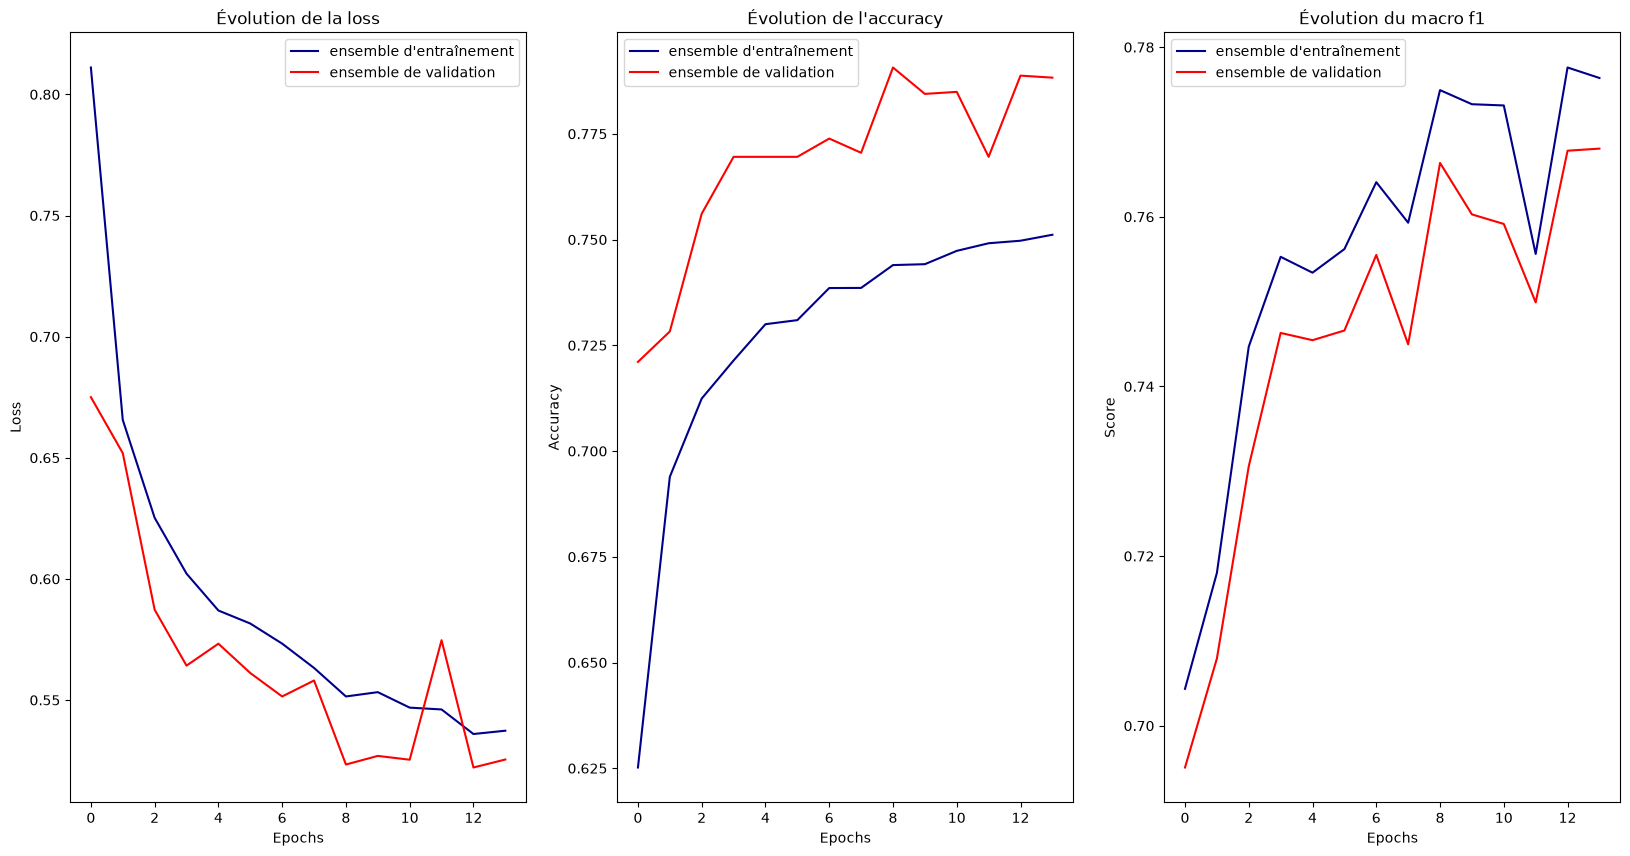

In [20]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [21]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 297ms/step


In [22]:
y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

[0 0 0 ... 3 3 3]


In [23]:
print(classification_report(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.60      0.74      0.66       337
           1       0.82      0.78      0.80       599
           2       0.89      0.80      0.84      1014
           3       0.67      0.96      0.79       134

    accuracy                           0.79      2084
   macro avg       0.75      0.82      0.77      2084
weighted avg       0.81      0.79      0.80      2084



[[249  43  44   1]
 [ 81 468  50   0]
 [ 84  59 810  61]
 [  1   1   4 128]]


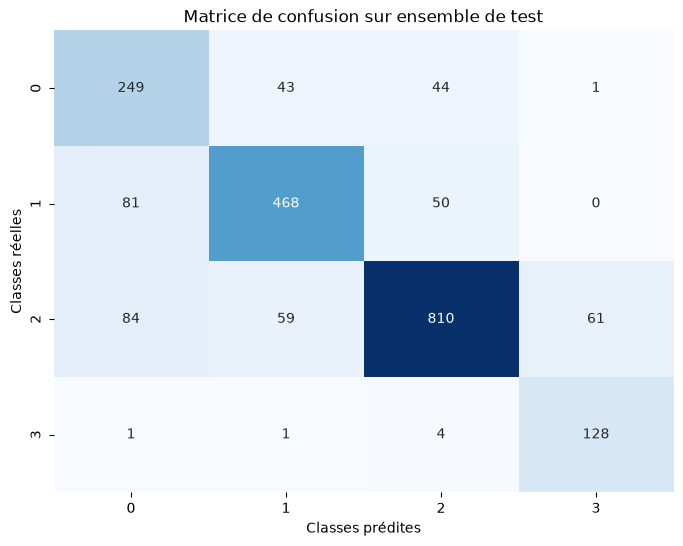

In [24]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)
    
print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

7. Fine tuning

In [25]:
#Degel des couches inférieures : On ne dégel que le dernier bloc de convolution (block7a)
for i, layer in enumerate(base_model.layers):
    if layer.name.startswith('block7'):
            break
    freeze_from = i
for layer in model.layers[freeze_from:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [26]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=8,
                             min_delta=0.001,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [29]:
fine_tuned_history=model.fit(train_ds, validation_data=val_ds,
                            epochs=40,
                            class_weight=class_weight_dict,
                            callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

model.save("cnn_fine_tuned_EfficientNet_ClassWeight.keras")
print("fine tuned modèle sauvegardé")

Epoch 1/40


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7507 - loss: 0.5422
Train F1 : 0.7816 | Val F1 : 0.7710
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 689s 657ms/step - accuracy: 0.7507 - loss: 0.5422 - val_accuracy: 0.7926 - val_loss: 0.5164 - learning_rate: 1.0000e-05 - train_f1_macro: 0.7816 - val_f1_macro: 0.7710
Epoch 2/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7522 - loss: 0.5355
Train F1 : 0.7812 | Val F1 : 0.7717
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 655s 629ms/step - accuracy: 0.7522 - loss: 0.5355 - val_accuracy: 0.7940 - val_loss: 0.5161 - learning_rate: 1.0000e-05 - train_f1_macro: 0.7812 - val_f1_macro: 0.7717
Epoch 3/40
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7533 - loss: 0.5373
Train F1 : 0.7802 | Val F1 : 0.7720
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 671s 644ms/step - accuracy: 0.7533 - loss: 0.5373 - val_accuracy: 0.7940 - val_loss: 0.5191 - learning_rate: 1.0000e-05 - train_f1_macro: 0.7802 - val_f1_macro: 0.7720
Epoch 4/40
1042/1042 ━━━━━━━━━━━━━━━

8. Évaluation du modèle après fine tuning

In [30]:
train_acc_fine=fine_tuned_history.history["accuracy"]
val_acc_fine=fine_tuned_history.history["val_accuracy"]

train_loss_fine=fine_tuned_history.history["loss"]
val_loss_fine=fine_tuned_history.history["val_loss"]

train_f1_fine=fine_tuned_history.history["train_f1_macro"]
val_f1_fine=fine_tuned_history.history["val_f1_macro"]

nb_epochs_fine=len(train_acc_fine)
print(nb_epochs_fine)
print(np.arange(nb_epochs_fine)+nb_epochs)

14
[14 15 16 17 18 19 20 21 22 23 24 25 26 27]


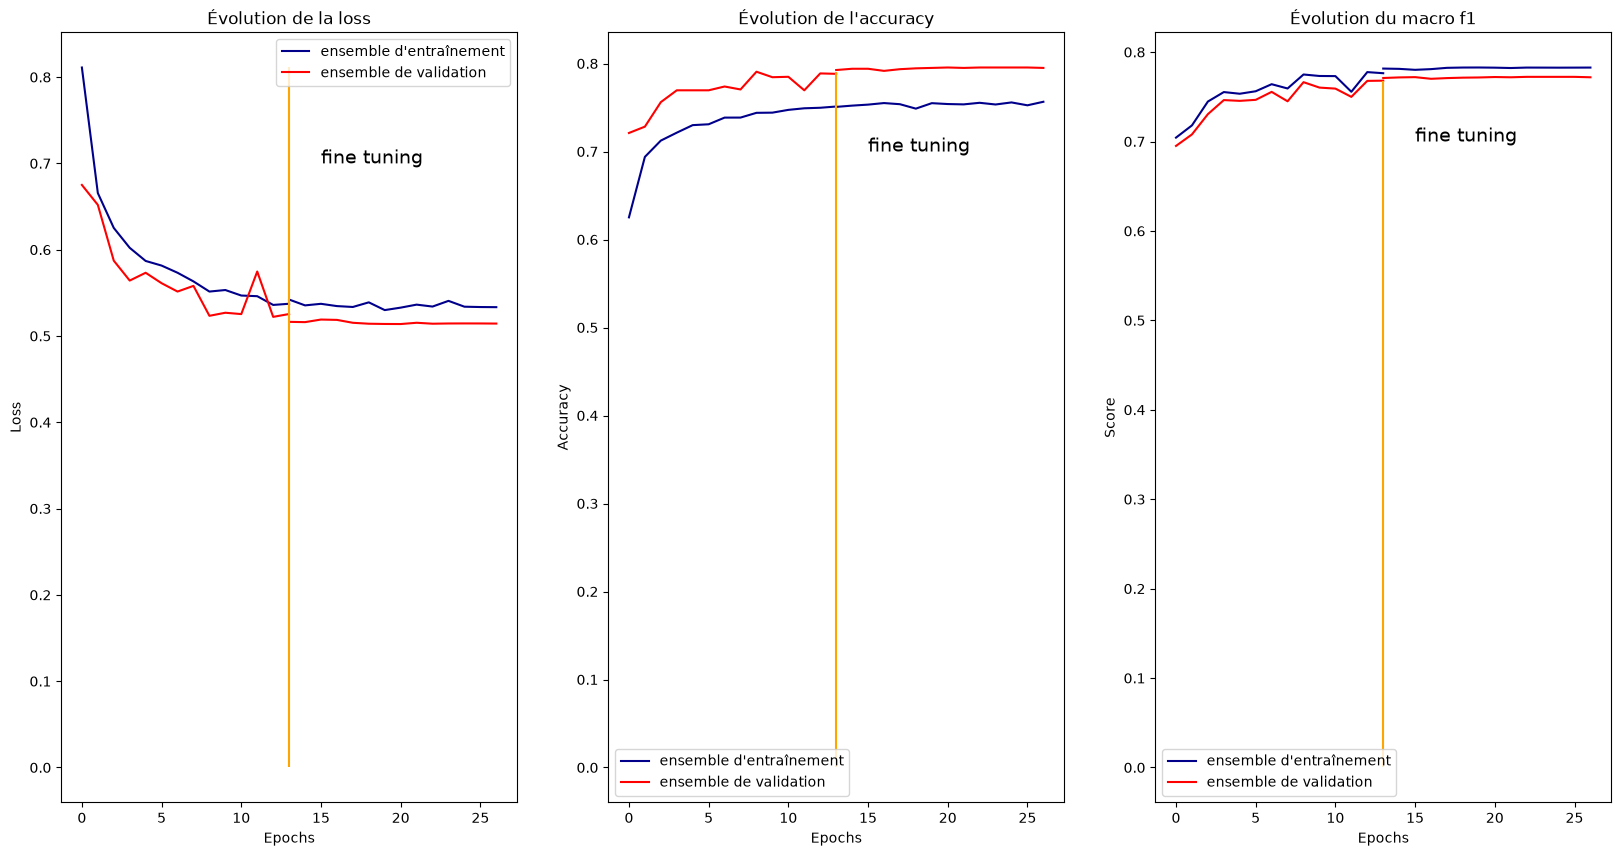

In [31]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_loss_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_loss_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(train_loss), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_acc_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_acc_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(val_acc), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_f1_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_f1_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(val_f1), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [32]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

print(classification_report(y_test_class, y_pred_class))

66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 287ms/step
[0 0 0 ... 3 3 3]
              precision    recall  f1-score   support

           0       0.61      0.73      0.66       337
           1       0.82      0.78      0.80       599
           2       0.89      0.81      0.85      1014
           3       0.68      0.96      0.80       134

    accuracy                           0.80      2084
   macro avg       0.75      0.82      0.78      2084
weighted avg       0.81      0.80      0.80      2084



[[245  42  49   1]
 [ 79 469  51   0]
 [ 75  58 823  58]
 [  1   1   4 128]]


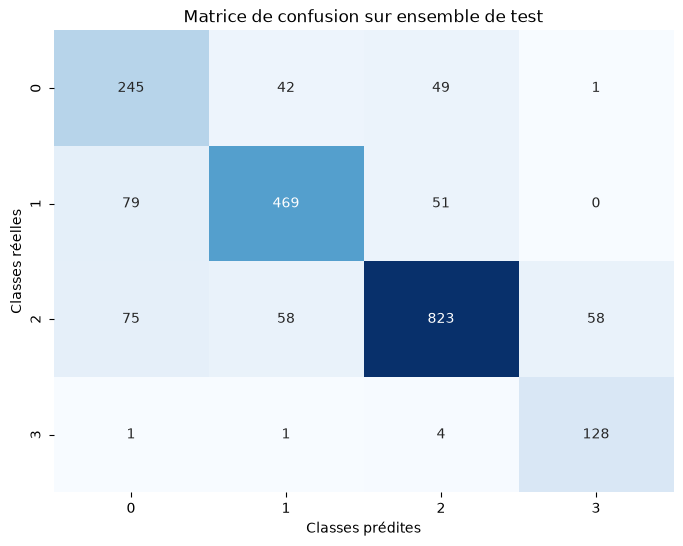

In [33]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)

print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()